## makemore: becoming a backprop ninja

swole doge style

手动实现反向传播（backpropagation）的张量版本

In [4]:
# there no change change in the first several cells from last lecture

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [6]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [7]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [8]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [9]:
# ok biolerplate done, now we get to the action:

In [10]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  # 检查是否完全相等（逐元素都相同）
  ex = torch.all(dt == t.grad).item()
  # 检查是否近似相等（允许很小的数值误差）
  app = torch.allclose(dt, t.grad)
  # 计算最大绝对误差
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [11]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [12]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [40]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3554, grad_fn=<NegBackward0>)

## Exercise 1

In [41]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one

# 注意：这里的 dx 不表示 x 的微分，而是 loss 对 x 的梯度（导数）

# tips: 数学上的对称性
    # 前向的sum求和 -> 后向的广播（复制）
    # 前向的广播（复制） -> 后向的sum求和

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
dprobs = (1.0 / probs) * dlogprobs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
dcounts += torch.ones_like(counts) * dcounts_sum
dnorm_logits = counts * dcounts
dlogits = dnorm_logits.clone() # 必须加clone，否则后续操作会影响dnorm_logits本身的值
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
# dlogits[torch.arange(n), logits.argmax(dim=1)] += dlogit_maxes.view(-1) # logits.argmax(dim=1) 等价于 logits.max(1).indices
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes # [32, 27] * [32, 1]
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1 - h**2) * dh
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = -0.5*(bnvar + 1e-5)**-1.5 * dbnvar_inv
dbndiff2 = 1/(n-1)*torch.ones_like(bndiff2) * dbnvar
dbndiff += 2*bndiff * dbndiff2
dhprebn = dbndiff.clone() # 必须加clone，否则后续操作会影响dbndiff本身的值
dbnmeani = -dbndiff.sum(0, keepdim=True)
dhprebn += 1/n * dbnmeani * torch.ones_like(hprebn)
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for i in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        dC[Xb[i, j]] += demb[i, j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [123]:
# eg. 如何计算 dcounts_sum_inv ?

# probs = counts * counts_sum_inv
print(counts.shape, counts_sum_inv.shape, probs.shape)
# c = a * b, but with tensors:
# a([3,3]) * b([3,1]) --->
# a11*b1 a12*b1 a13*b1
# a21*b2 a22*b2 a23*b2
# a31*b3 a32*b3 a33*b3
# c([3,3])

# 实际上有两个运算步骤：
# step1: copy b to match a's shape.     b[3,1] -> b_copied[3,3]
# step2: elementwise multiply.          a * b_copied -> c

# 求梯度时，依次backprop 乘法、复制 两个步骤
# db_copied = a * dc
# 将 b 视作计算图中的一个节点，复制相当于它被多次使用，反向传播过程中所有使用的梯度会累加，so：
# db = db_copied.sum(1) = (a * dc).sum(1)
# 并且 dcounts_sum_inv 要保持 counts_sum_inv 的 shape，所以 keepdim

dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
print((counts * dprobs).sum(1, keepdim=True).shape, counts_sum_inv.shape)

torch.Size([32, 27]) torch.Size([32, 1]) torch.Size([32, 27])
torch.Size([32, 1]) torch.Size([32, 1])


In [145]:
# eg. 如何计算 dh, dW2
# tips: 让其维度匹配就可得到正确答案

# logits = h @ W2 + b2
print(h.shape, W2.shape, b2.shape, logits.shape)
# x([2,3]) @ y([3,2]) -> z([2,2])
# x11*y11 + x12*y21 + x13*y31   x11*y12 + x12*y22 + x13*y32
# x21*y11 + x22*y21 + x23*y31   x21*y12 + x22*y22 + x23*y32

# dx(dh)
# dx11 = y11 * dz[0,0] + y12 * dz[0,1] + ... + y1k * dz[0,k-1]       = y[0,:] * dz[0,:]
# dx12 = y21 * dz[0,0] + y22 * dz[0,1] + ... + y2k * dz[0,k-1]       = y[1,:] * dz[0,:]
# dx23 = y31 * dz[1,0] + y32 * dz[1,1] + ... + y3k * dz[1,k-1]       = y[2,:] * dz[1,:]
# dxij = yj1 * dz[i-1,0] + yj2 * dz[i-1,1] + ... + yjk * dz[i-1,k-1] = y[j-1,:] * dz[i-1,:]
#      = y[j-1,:] * dz[i-1,:]
#      = dz[i-1,:] * yT[:, j-1]
# dx[i,j] = dz[i,:] * yT[:, j]
# dx([2,3]) = dz([2,2]) @ yT([2,3])
dh = dlogits @ W2.T
print(dlogits.shape, W2.T.shape, dh.shape)

# dy(dW2)
# dy11 = x11 * dz[0,0] + x21 * dz[1,0] = x[:,0] * dz[:,0]
# dy12 = x11 * dz[0,1] + x21 * dz[1,1] = x[:,0] * dz[:,1]
# dy21 = x12 * dz[0,0] + x22 * dz[1,0] = x[:,1] * dz[:,0]
# dy22 = x12 * dz[0,1] + x22 * dz[1,1] = x[:,1] * dz[:,1]
# dyij = x[:,i-1] * dz[:,j-1]
# dy[i,j] = x[:,i] * dz[:,j] = xT[i,:] * dz[:,j]
# dy([3,2]) = xT([3,2]) @ dz([2,2])
dW2 = h.T @ dlogits
print(h.T.shape, dlogits.shape, dW2.shape)

torch.Size([32, 64]) torch.Size([64, 27]) torch.Size([27]) torch.Size([32, 27])
torch.Size([32, 27]) torch.Size([27, 64]) torch.Size([32, 64])
torch.Size([64, 32]) torch.Size([32, 27]) torch.Size([64, 27])


## Exercise 2

In [36]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.3554320335388184 diff: 0.0


In [51]:
# backward pass

# way1
# dlogits = (F.softmax(logits, 1) - F.one_hot(Yb, num_classes=logits.shape[1])) / n

# way2
dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 6.05359673500061e-09


tensor([0.0757, 0.0783, 0.0183, 0.0504, 0.0183, 0.0867, 0.0227, 0.0368, 0.0180,
        0.0303, 0.0340, 0.0349, 0.0367, 0.0301, 0.0376, 0.0135, 0.0084, 0.0178,
        0.0161, 0.0591, 0.0513, 0.0231, 0.0265, 0.0677, 0.0582, 0.0266, 0.0232],
       grad_fn=<SelectBackward0>)
tensor(8)
tensor([ 0.0757,  0.0783,  0.0183,  0.0504,  0.0183,  0.0867,  0.0227,  0.0368,
        -0.9820,  0.0303,  0.0340,  0.0349,  0.0367,  0.0301,  0.0376,  0.0135,
         0.0084,  0.0178,  0.0161,  0.0591,  0.0513,  0.0231,  0.0265,  0.0677,
         0.0582,  0.0266,  0.0232], grad_fn=<MulBackward0>)
tensor(-9.3132e-10, grad_fn=<SumBackward0>)


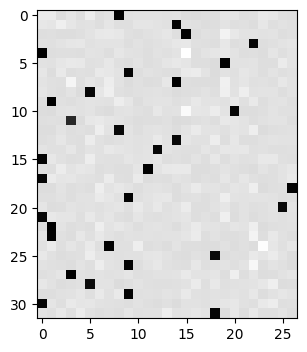

In [63]:
# 对于每一个样本（行），dlogits 中的数值可以被视作作用在概率分布上的力

# 查看第一个样本的概率分布
print(F.softmax(logits, 1)[0])

# 通过在对应位置减去 1（dlogits[range(n), Yb] -= 1）来施加一个“拉力”（Pull up），试图提高正确类别的概率
# 如果模型错误地自信（给错误类别分配了极高概率），那么该错误位置会收到一个巨大的“向下推”的力，同时正确位置会收到一个相等的“向上拉”的力
print(Yb[0])
print(dlogits[0] * n)

# 在一个样本的预测中，模型施加的吸引力（对正确类别的拉扯）和排斥力（对错误类别的推动）是完全平衡的
print(dlogits[0].sum())

# 可视化含义
# 黑色斑点： 代表负梯度，即正确标签所在的位置，它们正在被向上拉
# 灰色/白色区域： 代表正梯度，即错误类别，它们正在被向下推
# 由于整个矩阵中只有每行的一个位置被减去了 1，因此可视化图会呈现出背景为灰白色、仅有少数黑色斑点（正确标签点）的特征
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray');

## Exercise 3

In [64]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [83]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [278]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

## Exercise 4

In [93]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    #loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    # 2nd layer backprop
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # tanh
    dhpreact = (1.0 - h**2) * dh
    # batchnorm backprop
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 1st layer
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # embedding
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

  #   if i >= 100: # TODO: delete early breaking when you're ready to train the full net
  #     break

12297
      0/ 200000: 3.8327
  10000/ 200000: 2.1761
  20000/ 200000: 2.3813
  30000/ 200000: 2.4236
  40000/ 200000: 1.9146
  50000/ 200000: 2.4300
  60000/ 200000: 2.3706
  70000/ 200000: 2.0439
  80000/ 200000: 2.3005
  90000/ 200000: 2.1504
 100000/ 200000: 1.9070
 110000/ 200000: 2.2258
 120000/ 200000: 2.0450
 130000/ 200000: 2.3812
 140000/ 200000: 2.3171
 150000/ 200000: 2.1667
 160000/ 200000: 2.0545
 170000/ 200000: 1.8776
 180000/ 200000: 2.0712
 190000/ 200000: 1.8503


In [92]:
# useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

(27, 10)        | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08
(30, 200)       | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
(200,)          | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
(200, 27)       | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08
(27,)           | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08


In [94]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)


In [97]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0717313289642334
val 2.111687421798706


In [294]:
# I achieved:
# train 2.0718822479248047
# val 2.1162495613098145

In [98]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # ------------
      # forward pass:
      # Embedding
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

mora.
mayah.
see.
madhayla.
reisha.
endra.
gradelynnelin.
shi.
jen.
eden.
estanar.
kayzion.
kamin.
shubergihimaest.
jair.
jennex.
teron.
ubelled.
ryyah.
fael.
